In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Load the 4 cleaned files
df_orders = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/orders.parquet")
df_items = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/order_items.parquet")
df_customers = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/customers.parquet")
df_products = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/products.parquet")


In [ ]:

# Join all 4 tables together at the order-item grain
df_master = (
    df_items.merge(df_orders, on="order_id", how="inner")
    .merge(df_customers, on="customer_id", how="inner")
    .merge(df_products, on="product_id", how="inner")
)

# Filter strictly to delivered orders for accurate operational/sales metrics
df_master = df_master[df_master["order_status"] == "delivered"].copy()


In [ ]:
# Feature Engineering: Fulfillment & Total Value
df_master["total_item_value"] = df_master["price"] + df_master["freight_value"]
df_master["delivery_lead_time_days"] = (
    df_master["order_delivered_customer_date"] - df_master["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)
df_master["order_month"] = df_master["order_purchase_timestamp"].dt.to_period("M")

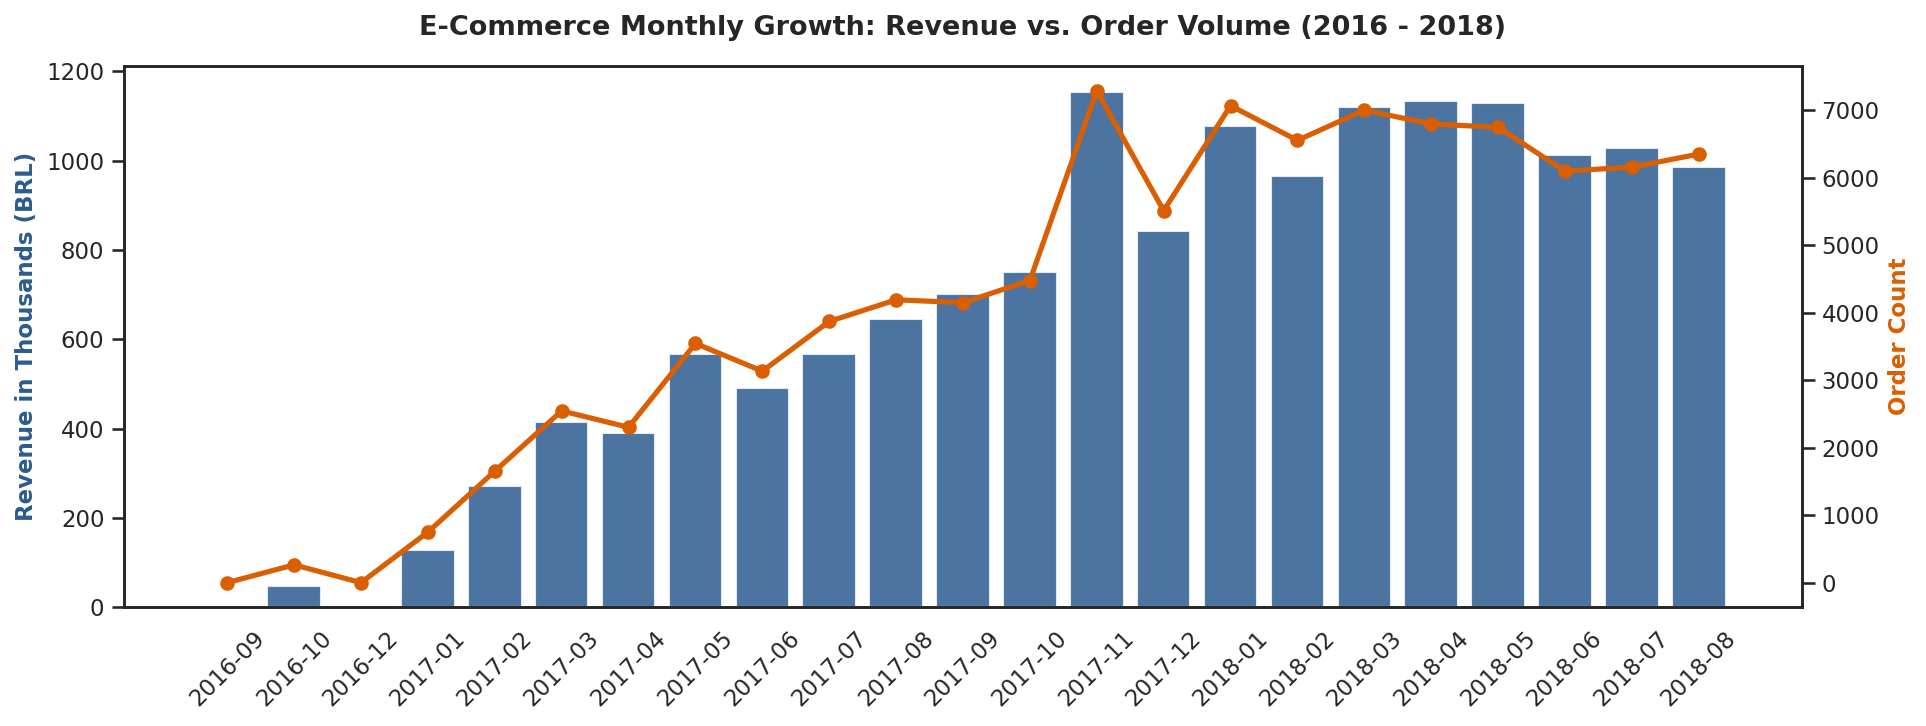

In [ ]:
# MONTHLY REVENUE & ORDER VOLUME

monthly_perf = df_master.groupby("order_month").agg(
    total_revenue=("total_item_value", "sum"),
    order_volume=("order_id", "nunique")
).reset_index()
monthly_perf["order_month_str"] = monthly_perf["order_month"].astype(str)

fig, ax1 = plt.subplots(figsize=(13, 5), dpi=150)
# Bar chart: Revenue
ax1.bar(
    monthly_perf["order_month_str"],
    monthly_perf["total_revenue"] / 1000,
    color="#2b5c8f",
    alpha=0.85,
    label="Gross Revenue (k BRL)"
)
ax1.set_ylabel("Revenue in Thousands (BRL)", color="#2b5c8f", fontsize=11, fontweight="bold")
ax1.tick_params(axis="x", rotation=45)

# Line chart: Order Volume
ax2 = ax1.twinx()
ax2.plot(
    monthly_perf["order_month_str"],
    monthly_perf["order_volume"],
    color="#d95f02",
    linewidth=2.5,
    marker="o",
    label="Unique Orders"
)
ax2.set_ylabel("Order Count", color="#d95f02", fontsize=11, fontweight="bold")
ax2.grid(False)

plt.title("E-Commerce Monthly Growth: Revenue vs. Order Volume (2016 - 2018)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/eda_monthly_sales_trend.png")
plt.show()

In [ ]:
# TOP 10 PRODUCT CATEGORIES BY REVENUE & AOV

top_cats = (
    df_master.groupby("category_name")
    .agg(
        total_revenue=("total_item_value", "sum"),
        order_count=("order_id", "nunique")
    )
    .assign(aov=lambda x: x["total_revenue"] / x["order_count"])
    .sort_values(by="total_revenue", ascending=False)
    .head(10)
    .reset_index()
)

/tmp/ipykernel_2860/1564833728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


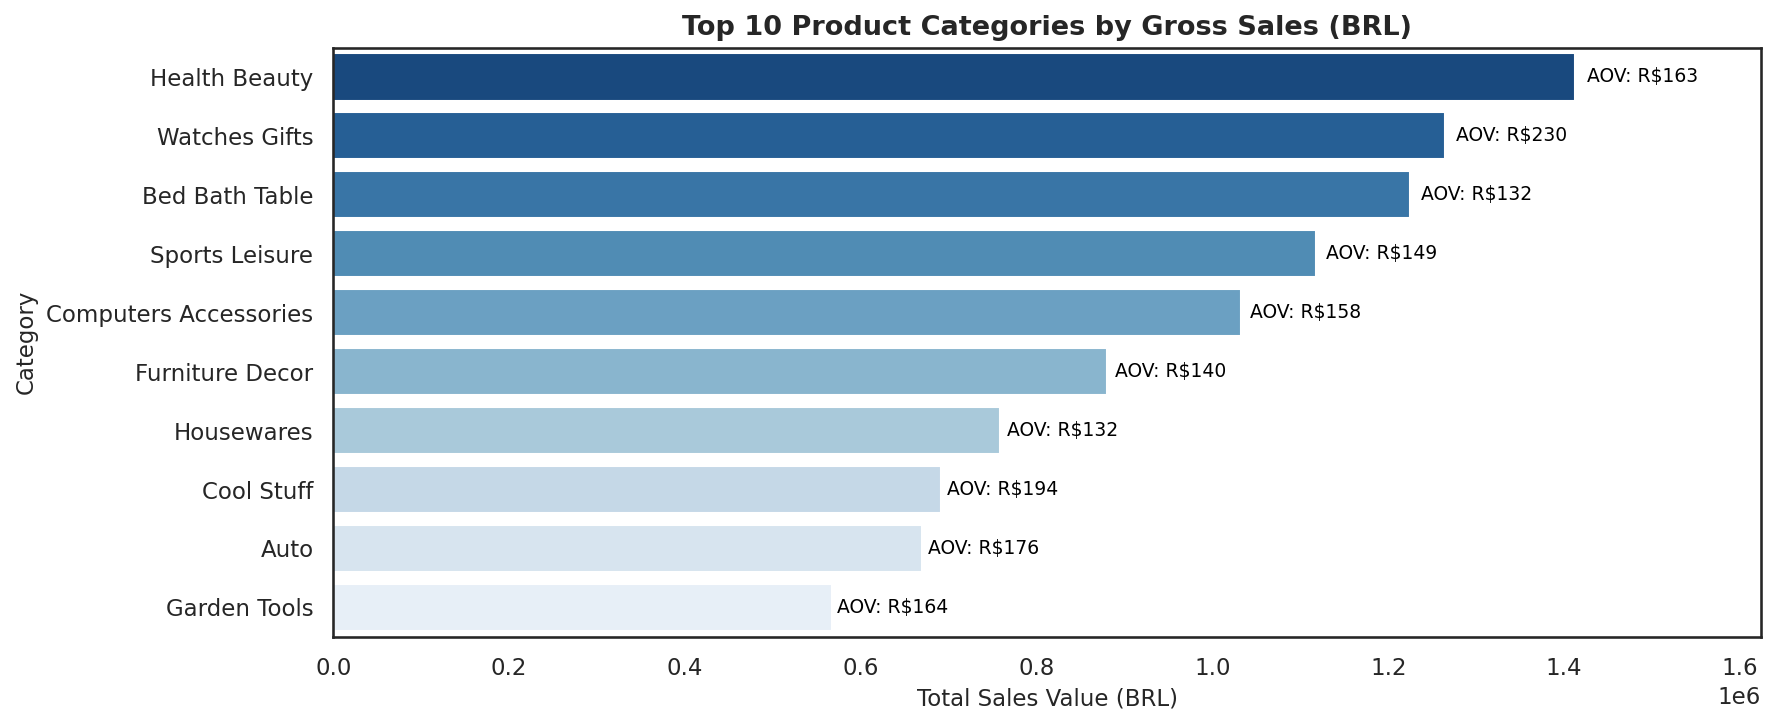

In [ ]:
plt.figure(figsize=(12, 5), dpi=150)
bars = sns.barplot(
    data=top_cats,
    x="total_revenue",
    y="category_name",
    palette="Blues_r"
)
plt.title("Top 10 Product Categories by Gross Sales (BRL)", fontsize=13, fontweight="bold")
plt.xlabel("Total Sales Value (BRL)", fontsize=11)
plt.ylabel("Category", fontsize=11)

# Annotate bars with Average Order Value (AOV)
for index, row in top_cats.iterrows():
    bars.text(
        row["total_revenue"] * 1.01,
        index,
        f"AOV: R${row['aov']:.0f}",
        color="black",
        va="center",
        fontsize=9
    )

plt.xlim(0, top_cats["total_revenue"].max() * 1.15)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/eda_top_categories_aov.png")
plt.show()

In [ ]:
# REGIONAL FULFILLMENT BOTTLENECK (LOGISTICS LAG)
state_logistics = (
    df_master.groupby("customer_state")
    .agg(
        avg_delivery_days=("delivery_lead_time_days", "mean"),
        total_orders=("order_id", "nunique")
    )
    .query("total_orders > 100") # Filter for statistically significant states
    .sort_values(by="avg_delivery_days", ascending=False)
    .reset_index()
)

/tmp/ipykernel_2860/1959081880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


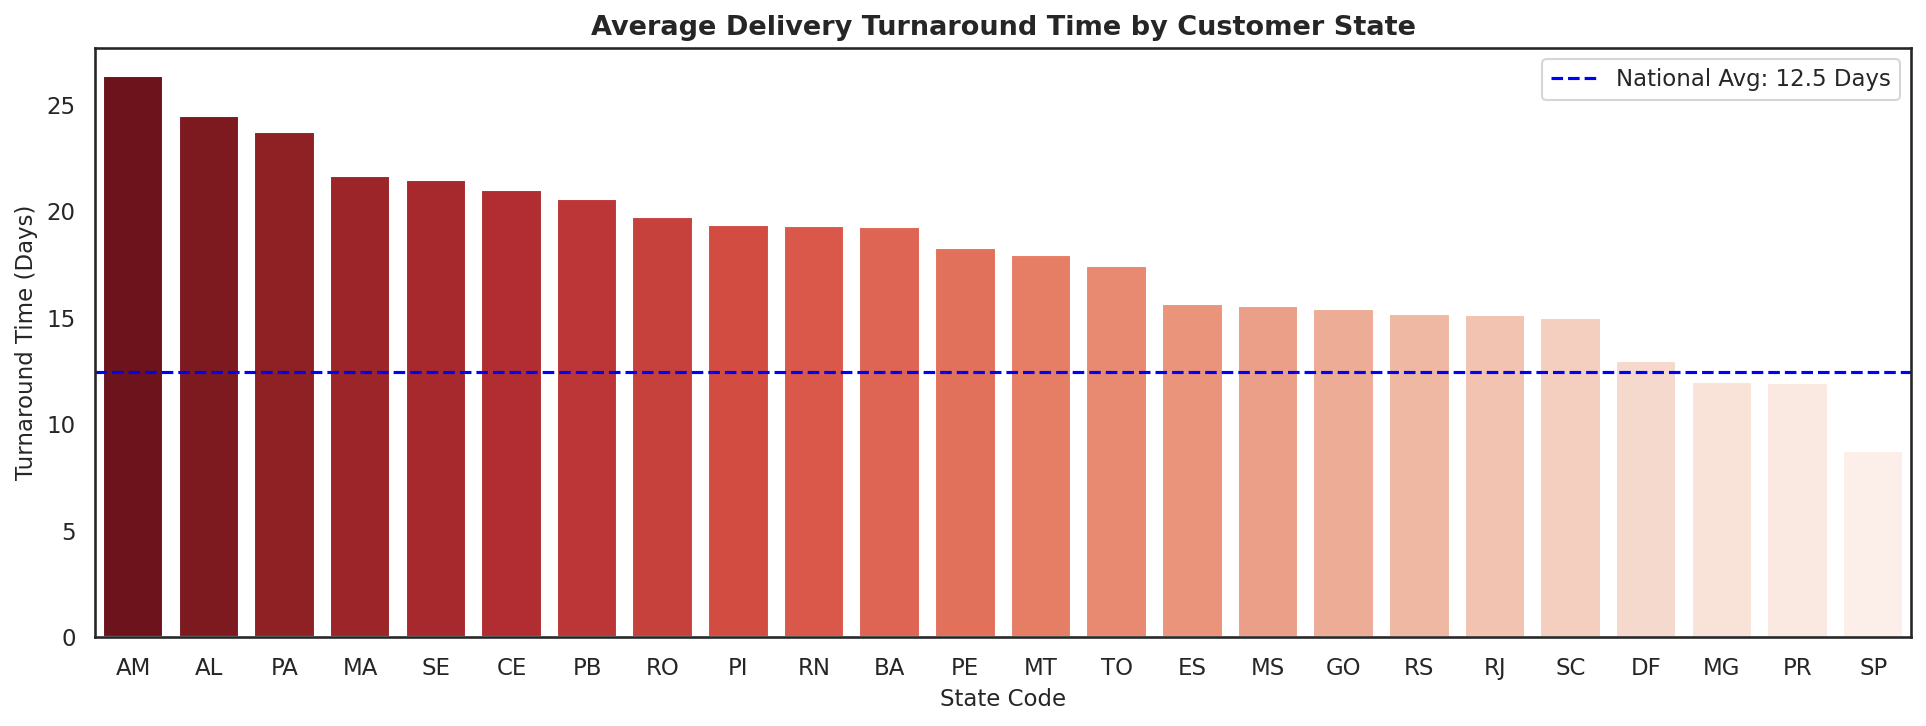

In [ ]:
plt.figure(figsize=(13, 5), dpi=150)
sns.barplot(
    data=state_logistics,
    x="customer_state",
    y="avg_delivery_days",
    palette="Reds_r"
)
plt.axhline(
    df_master["delivery_lead_time_days"].mean(),
    color="blue",
    linestyle="--",
    linewidth=1.5,
    label=f"National Avg: {df_master['delivery_lead_time_days'].mean():.1f} Days"
)
plt.title("Average Delivery Turnaround Time by Customer State", fontsize=13, fontweight="bold")
plt.xlabel("State Code", fontsize=11)
plt.ylabel("Turnaround Time (Days)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/eda_logistics_by_state.png")
plt.show()

Loading orders and customer datasets...
Retention matrix saved to assets/cohort_retention_matrix.csv
Heatmap visualization successfully saved to: /content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/assets/cohort_retention_heatmap.png


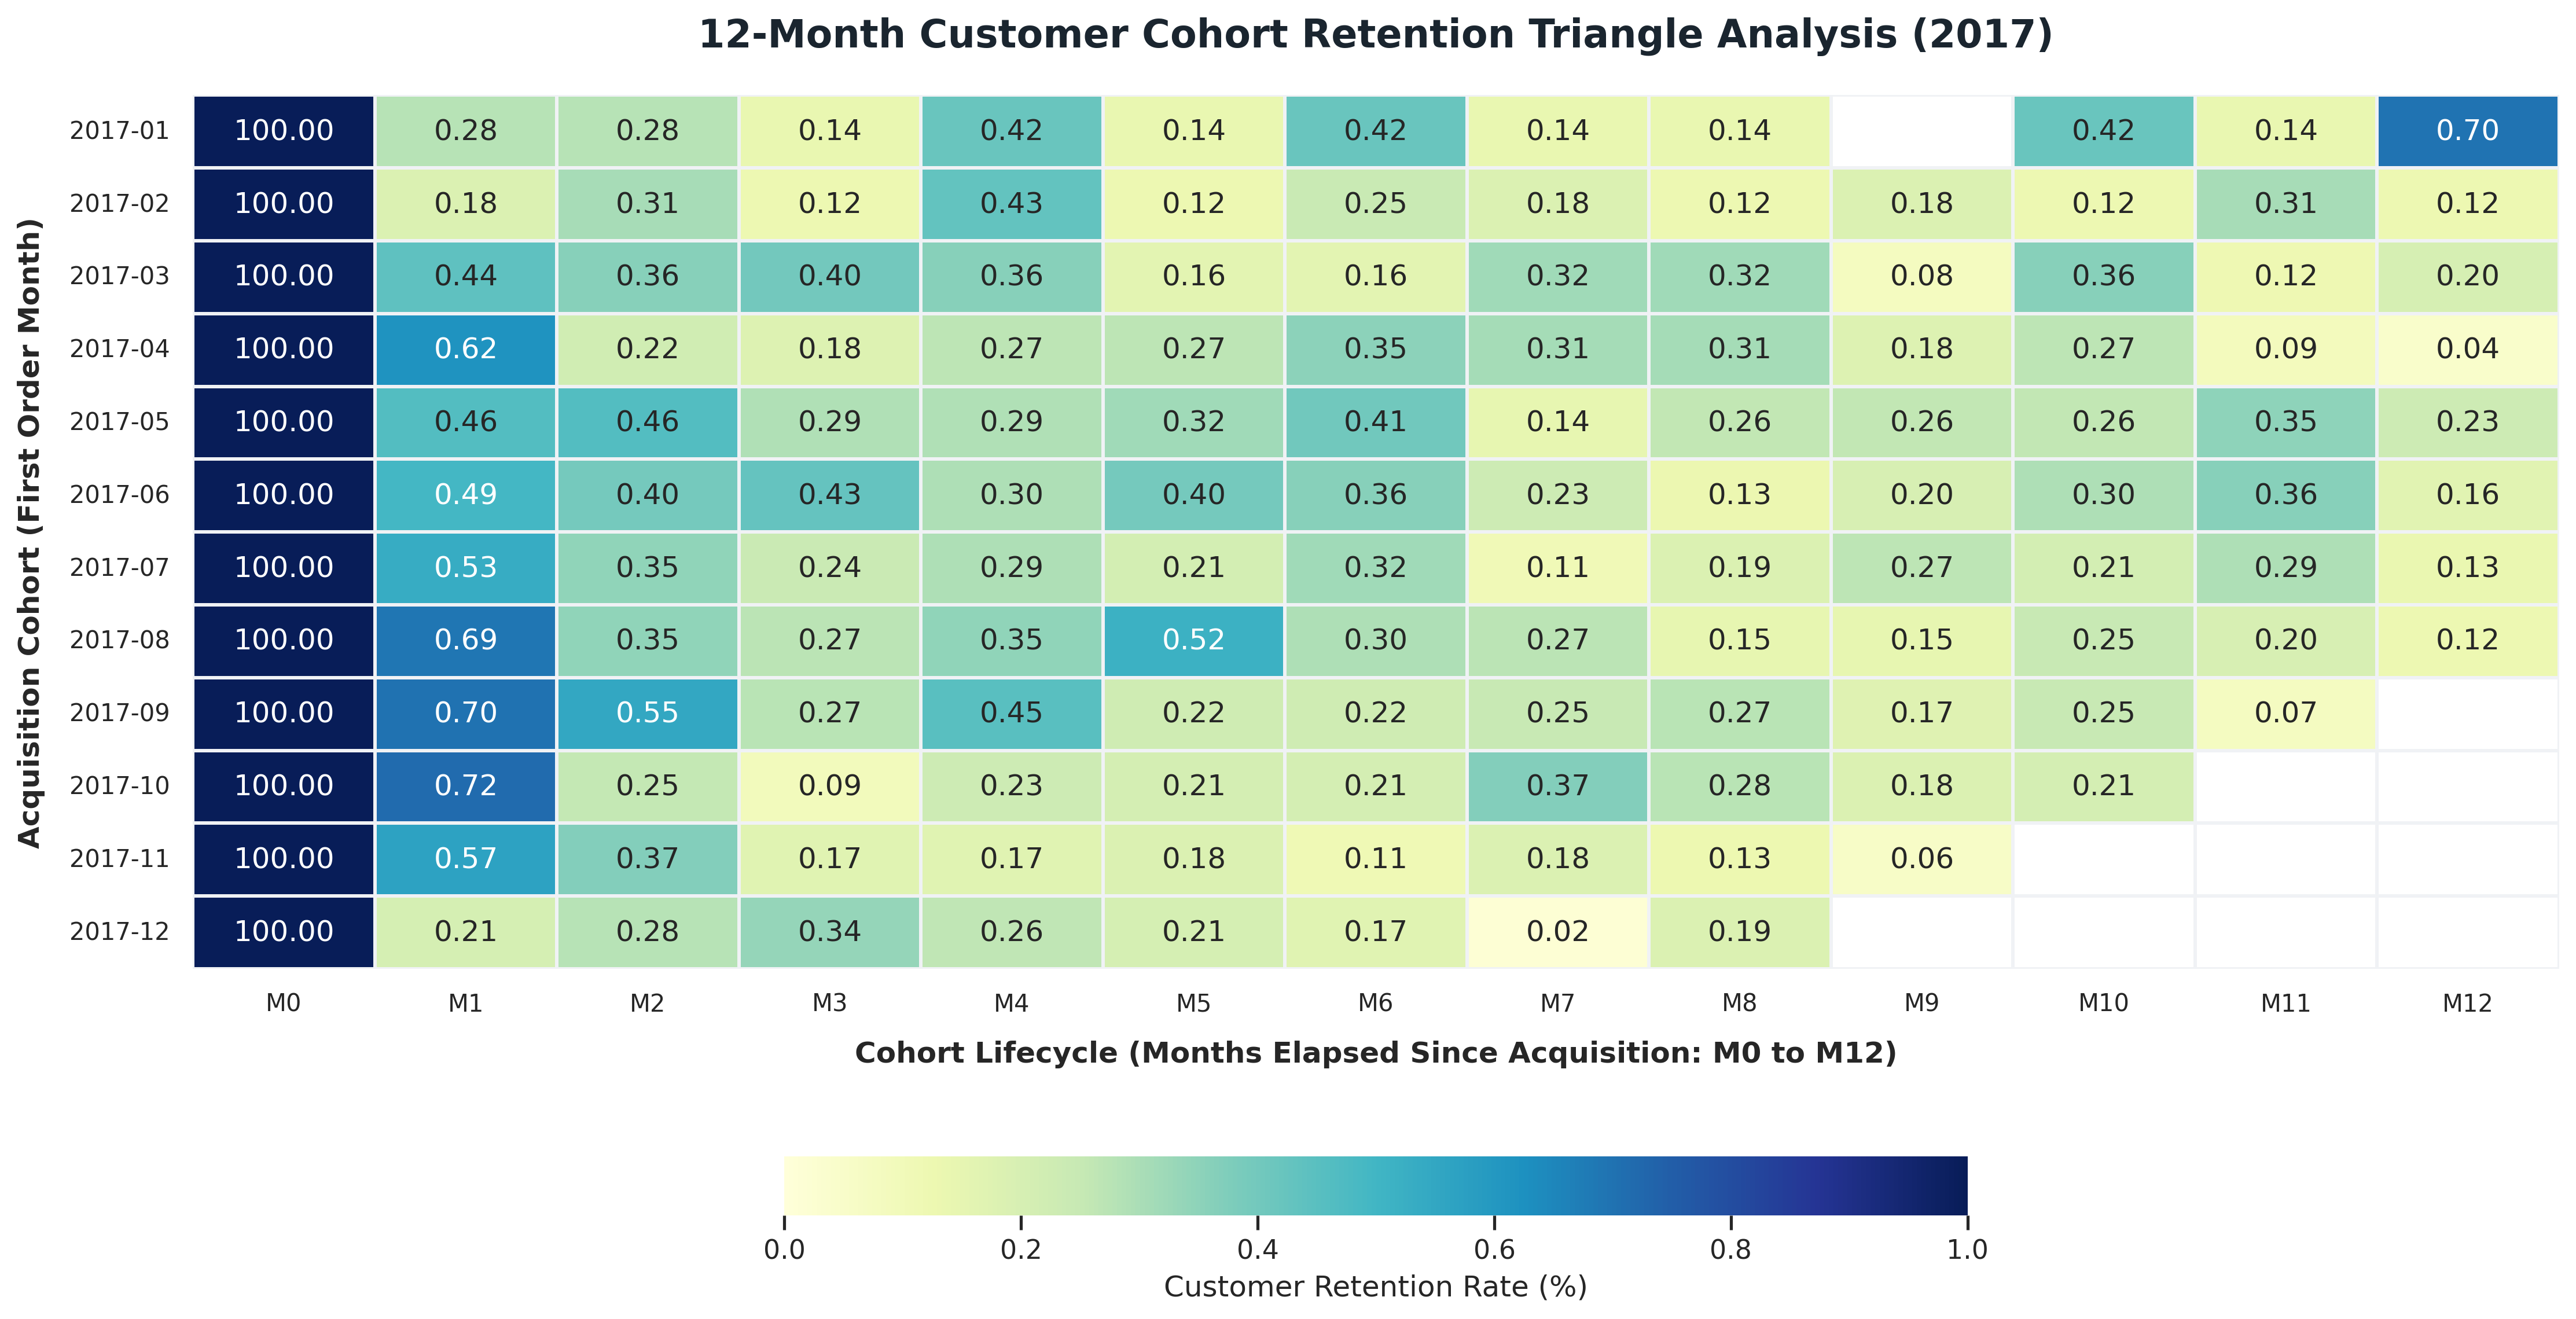

In [ ]:
# ==============================================================================
# SCRIPT: 04_cohort_retention_matrix.py (or run in Colab notebook)
# DESCRIPTION: Computes 12-Month User Cohort Retention Matrix & Seaborn Heatmap
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Setup Output Directory
ASSETS_DIR = Path("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/assets")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# 2. Ingest Cleaned Data
print("Loading orders and customer datasets...")
# Using the clean CSVs or Parquet files created in Step 1
df_orders = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/orders.parquet")
df_customers = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/E-Commerce Omnichannel Sales Performance & Cohort Retention/data/processed/customers.parquet")

# Ensure datetimes are properly parsed
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"])

# 3. Filter strictly for delivered orders to eliminate non-fulfilled noise
df_delivered = df_orders[df_orders["order_status"] == "delivered"].copy()

# 4. Join Orders with Customers to attach customer_unique_id
# (Crucial: customer_unique_id represents the actual human buyer)
df_cohort_base = df_delivered.merge(
    df_customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="inner"
)

# 5. Extract Order Purchase Month (YYYY-MM)
df_cohort_base["order_month"] = df_cohort_base["order_purchase_timestamp"].dt.to_period("M")

# 6. Determine Each Customer's Initial Acquisition Cohort (First purchase month)
df_cohort_base["cohort_group"] = (
    df_cohort_base.groupby("customer_unique_id")["order_purchase_timestamp"]
    .transform("min")
    .dt.to_period("M")
)

# 7. Calculate Cohort Index (Months Elapsed Since First Purchase: 0, 1, 2, ..., 12)
year_diff = df_cohort_base["order_month"].dt.year - df_cohort_base["cohort_group"].dt.year
month_diff = df_cohort_base["order_month"].dt.month - df_cohort_base["cohort_group"].dt.month
df_cohort_base["cohort_index"] = year_diff * 12 + month_diff

# 8. Filter for standard 2017 cohorts (where a full 12-month lifecycle is observable)
# (Late 2018 cohorts have not lived 12 months yet)
df_filtered = df_cohort_base[
    (df_cohort_base["cohort_group"] >= "2017-01") &
    (df_cohort_base["cohort_group"] <= "2017-12") &
    (df_cohort_base["cohort_index"].between(0, 12))
].copy()

# 9. Aggregate Unique Active Customers per Cohort per Elapsed Month
cohort_pivot_counts = (
    df_filtered.groupby(["cohort_group", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index()
    .pivot(index="cohort_group", columns="cohort_index", values="customer_unique_id")
)

# 10. Compute Percentage Retention Matrix
# (Divide every month's user count by Month 0 baseline)
cohort_sizes = cohort_pivot_counts.iloc[:, 0]
retention_matrix = cohort_pivot_counts.divide(cohort_sizes, axis=0) * 100

# Format index as string for clean display on y-axis
retention_matrix.index = retention_matrix.index.astype(str)

# 11. Save Retention Matrix Table to CSV for GitHub Documentation
retention_matrix.to_csv(ASSETS_DIR / "cohort_retention_matrix.csv")
print("Retention matrix saved to assets/cohort_retention_matrix.csv")

# ==============================================================================
# 12. RENDER PUBLICATION-READY SEABORN HEATMAP (TRIANGLE MATRIX)
# ==============================================================================
plt.figure(figsize=(15, 8), dpi=300)

# Set clean styling
sns.set_theme(style="white")

# Define color palette: Mask Month 0 (100%) with a distinct color or cap colormap
# Note: Since marketplace retention drops below 1% quickly, vmax=1.5 gives high contrast
heatmap = sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,  # Caps intensity to bring out subtle variations in 0.20% - 0.90% repeat rates
    linewidths=1.0,
    linecolor="#f0f2f5",
    cbar_kws={
        "label": "Customer Retention Rate (%)",
        "orientation": "horizontal",
        "pad": 0.15,
        "shrink": 0.5
    }
)

# Titles and Axis Formatting
plt.title(
    "12-Month Customer Cohort Retention Triangle Analysis (2017)",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#1a252f"
)
plt.xlabel("Cohort Lifecycle (Months Elapsed Since Acquisition: M0 to M12)", fontsize=12, labelpad=10, fontweight="bold")
plt.ylabel("Acquisition Cohort (First Order Month)", fontsize=12, labelpad=10, fontweight="bold")

# Adjust tick labels
plt.xticks(ticks=np.arange(13) + 0.5, labels=[f"M{i}" for i in range(13)], fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

# Save the visualization directly
output_img_path = ASSETS_DIR / "cohort_retention_heatmap.png"
plt.savefig(output_img_path, dpi=300, bbox_inches="tight")
print(f"Heatmap visualization successfully saved to: {output_img_path}")
plt.show()